# GridSense  
## Learning Electricity Outage Patterns from Community Reports in Addis Ababa

**Student:** Lisanegebriel  
**Country:** Ethiopia  
**Course:** Kujenga Final Project  

Electricity outages are not just technical events. In Addis Ababa, they affect studying, internet access, household routines, small businesses, food storage, and productivity. I chose this project because it is a problem I see in daily life, and because it is exactly the kind of local question Kujenga encourages: start with a real issue in your community, collect or organize data, use mathematical and computational tools, and tell a careful story.

In this notebook, I analyze **anonymous community-reported electricity outage data** collected from Addis Ababa. I avoid using synthetic data as the main dataset. The goal is not to claim that this small dataset can already replace official utility systems. Instead, the goal is to show how local outage reports can be collected responsibly, cleaned, analyzed, and shaped into a future machine-learning pipeline.

### Main research question

**What can anonymous community outage reports tell us about electricity outage patterns in Addis Ababa, and how can these reports support a responsible future outage-risk prediction system?**

### Guiding questions

1. When are outages most commonly reported?
2. Which sub-cities or sefers report the highest outage burden?
3. Are reported outage durations different for rainy/stormy conditions compared with non-rainy conditions?
4. Can we use regression to explain outage duration from time, weather, planning status, and location features?
5. Can this collected data support a simple machine-learning prototype for high-risk outage classification?

## 1. How this project fits Kujenga

Kujenga is about using mathematics, modelling, data science, and AI to investigate real-world problems. I use several Kujenga ideas in this project:

| Kujenga idea | Course example | How I use it here |
|---|---|---|
| Regression | Happiness and life expectancy | Model outage duration using time, weather, and location features |
| Hypothesis testing | Ethiopian vs Kenyan runners | Test whether rainy/stormy outage reports have longer duration |
| Dynamic systems thinking | SIR/SEIR epidemic models | Treat outage risk as something that changes over time and conditions |
| Network/PageRank thinking | Ranking webpages | Future extension: rank sub-cities by co-outage connections |
| Final project storytelling | Local problem + data + analysis | Collect anonymous Addis Ababa reports and tell a local data story |

The most important part is not just the model. The important part is asking a meaningful local question, using real data responsibly, showing the analysis clearly, and being honest about limitations.

## 2. Data sources and privacy

The main dataset is an anonymous community outage report dataset. It was collected for this project and does **not** contain names, phone numbers, emails, exact home addresses, or personal identification numbers.

The GitHub repository should include the dataset so tutors can run this notebook directly. If the notebook is opened from a cloned GitHub repository, it first tries to load the local CSV. If the notebook is opened somewhere else, it tries the raw GitHub URL.

### Important privacy rule

Free-text notes can accidentally contain personal information. For that reason, this notebook removes columns such as `notes`, `comments`, `phone`, `email`, `name`, and `address` from the analysis if they appear.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
import statsmodels.formula.api as smf

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, make_scorer
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

In [2]:
# ----------------------------
# Data loading configuration
# ----------------------------

# Update this if your GitHub username/repository changes.
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/lisan-5/GridSense/main"

# Candidate locations. The notebook tries local files first, then GitHub raw URLs.
COMMUNITY_DATA_CANDIDATES = [
    "../data/processed/community_outage_reports_clean.csv",
    "../data/raw/community_outage_reports.csv",
    "data/processed/community_outage_reports_clean.csv",
    "data/raw/community_outage_reports.csv",
    f"{GITHUB_RAW_BASE}/data/processed/community_outage_reports_clean.csv",
    f"{GITHUB_RAW_BASE}/data/raw/community_outage_reports.csv",
]

CONTEXT_DATA_CANDIDATES = [
    "../data/processed/local_evidence_dataset.csv",
    "data/processed/local_evidence_dataset.csv",
    f"{GITHUB_RAW_BASE}/data/processed/local_evidence_dataset.csv",
]

def read_csv_safely(source):
    # Read a CSV from a local path or URL with safe defaults.
    return pd.read_csv(
        source,
        encoding="utf-8-sig",
        engine="python",
        on_bad_lines="warn"
    )

def load_first_available(candidates, required=True, label="dataset"):
    # Try a list of local paths/URLs and return the first one that loads.
    errors = []
    for src in candidates:
        try:
            if src.startswith("http"):
                df_loaded = read_csv_safely(src)
                print(f"Loaded {label} from URL: {src}")
                return df_loaded, src
            path = Path(src)
            if path.exists():
                df_loaded = read_csv_safely(path)
                print(f"Loaded {label} from local file: {path}")
                return df_loaded, str(path)
        except Exception as exc:
            errors.append(f"{src}: {exc}")
    if required:
        raise FileNotFoundError(
            f"Could not load {label}. Tried:\n" +
            "\n".join(candidates) +
            "\n\nErrors:\n" +
            "\n".join(errors[:5])
        )
    return pd.DataFrame(), None

community_raw, community_source = load_first_available(
    COMMUNITY_DATA_CANDIDATES, required=True, label="community outage reports"
)

context_raw, context_source = load_first_available(
    CONTEXT_DATA_CANDIDATES, required=False, label="public context dataset"
)

print("community_raw shape:", community_raw.shape)
print("context_raw shape:", context_raw.shape)
community_raw.head()

Loaded community outage reports from local file: ..\data\processed\community_outage_reports_clean.csv
Loaded public context dataset from local file: ..\data\processed\local_evidence_dataset.csv
community_raw shape: (198, 13)
context_raw shape: (13, 10)


,report_id,date,sub_city,sefer_or_landmark,outage_start_time,outage_end_time,duration_hours,planned_notice,impact_level,weather_condition,source_type,confidence_score,high_risk_outage
0,COMM-00001,2026-04-12,Bole,Rwanda,03:00,05:01,2.02,no,medium,clear,streamlit_form,0.62,1
1,COMM-00002,2026-04-13,Gulele,Shiro Meda,23:00,23:23,0.39,yes,low,cloudy,streamlit_form,0.76,0
2,COMM-00003,2026-04-14,Akaki Kality,Kality,16:00,16:39,0.65,no,low,cloudy,streamlit_form,0.56,0
3,COMM-00004,2026-04-15,Lideta,Tor Hailoch,07:00,08:00,1.00,yes,low,rain,streamlit_form,0.79,0
4,COMM-00005,2026-04-16,Arada,Arat Kilo,05:00,06:00,1.00,yes,low,clear,streamlit_form,0.70,0


## 3. Initial inspection

Before cleaning, I inspect the columns, missing values, and a few sample rows. This helps me understand what the data contains and whether it is ready for analysis.

In [3]:
print("Community report columns:")
print(list(community_raw.columns))

print("\nFirst rows:")
display(community_raw.head())

print("\nData types:")
display(community_raw.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(community_raw.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nNumber of rows before cleaning:", len(community_raw))

Community report columns:
['report_id', 'date', 'sub_city', 'sefer_or_landmark', 'outage_start_time', 'outage_end_time', 'duration_hours', 'planned_notice', 'impact_level', 'weather_condition', 'source_type', 'confidence_score', 'high_risk_outage']

First rows:


,report_id,date,sub_city,sefer_or_landmark,outage_start_time,outage_end_time,duration_hours,planned_notice,impact_level,weather_condition,source_type,confidence_score,high_risk_outage
0,COMM-00001,2026-04-12,Bole,Rwanda,03:00,05:01,2.02,no,medium,clear,streamlit_form,0.62,1
1,COMM-00002,2026-04-13,Gulele,Shiro Meda,23:00,23:23,0.39,yes,low,cloudy,streamlit_form,0.76,0
2,COMM-00003,2026-04-14,Akaki Kality,Kality,16:00,16:39,0.65,no,low,cloudy,streamlit_form,0.56,0
3,COMM-00004,2026-04-15,Lideta,Tor Hailoch,07:00,08:00,1.00,yes,low,rain,streamlit_form,0.79,0
4,COMM-00005,2026-04-16,Arada,Arat Kilo,05:00,06:00,1.00,yes,low,clear,streamlit_form,0.70,0



Data types:


,dtype
report_id,object
date,object
sub_city,object
sefer_or_landmark,object
outage_start_time,object
outage_end_time,object
duration_hours,float64
planned_notice,object
impact_level,object
weather_condition,object



Missing values:


,missing_count
report_id,0
date,0
sub_city,0
sefer_or_landmark,0
outage_start_time,0
outage_end_time,0
duration_hours,0
planned_notice,0
impact_level,0
weather_condition,0



Number of rows before cleaning: 198


## 4. Data cleaning and privacy protection

The cleaning process does four things:

1. Standardizes column names.
2. Removes personal or risky free-text columns if present.
3. Converts dates, times, durations, and confidence scores to usable data types.
4. Removes duplicates and impossible values.

I also avoid interpreting report counts as official outage frequency. More reports in one area can mean more respondents, not necessarily more outages.

In [4]:
def standardize_column_names(df):
    clean = df.copy()
    clean.columns = (
        clean.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return clean

def remove_private_or_free_text_columns(df):
    # Drop columns likely to contain personal or unstructured sensitive information.
    risky_keywords = [
        "name", "phone", "email", "address", "exact_location", "gps",
        "latitude", "longitude", "comment", "comments", "note", "notes",
        "personal", "contact"
    ]
    cols_to_drop = [
        col for col in df.columns
        if any(keyword in col.lower() for keyword in risky_keywords)
    ]
    if cols_to_drop:
        print("Dropping privacy/free-text columns:", cols_to_drop)
    return df.drop(columns=cols_to_drop, errors="ignore"), cols_to_drop

def normalize_text(series):
    return series.astype(str).str.strip().str.lower().replace({"nan": np.nan, "none": np.nan, "": np.nan})

df = standardize_column_names(community_raw)
df, dropped_privacy_columns = remove_private_or_free_text_columns(df)

# Flexible column aliases. This makes the notebook more robust if form column names change slightly.
rename_candidates = {
    "date": ["date", "outage_date", "report_date", "day"],
    "outage_start_time": ["outage_start_time", "start_time", "time", "start"],
    "outage_end_time": ["outage_end_time", "end_time", "end"],
    "duration_hours": ["duration_hours", "duration", "outage_duration", "duration_in_hours"],
    "sub_city": ["sub_city", "subcity", "sub_city_name"],
    "sefer_or_landmark": ["sefer_or_landmark", "sefer", "area", "landmark", "neighborhood", "neighbourhood"],
    "planned_notice": ["planned_notice", "planned", "planned_or_unplanned", "was_it_planned"],
    "impact_level": ["impact_level", "impact", "severity", "disruption_level"],
    "weather_condition": ["weather_condition", "weather", "weather_status"],
    "source_type": ["source_type", "source"],
    "confidence_score": ["confidence_score", "confidence"],
    "report_id": ["report_id", "id"],
    "high_risk_outage": ["high_risk_outage", "high_risk", "risk_label"]
}

actual_renames = {}
for canonical, aliases in rename_candidates.items():
    if canonical not in df.columns:
        for alias in aliases:
            if alias in df.columns:
                actual_renames[alias] = canonical
                break

df = df.rename(columns=actual_renames)

# Create report_id if absent.
if "report_id" not in df.columns:
    df["report_id"] = [f"COMM-{i+1:05d}" for i in range(len(df))]

required_columns = ["date", "duration_hours", "sub_city", "planned_notice", "impact_level", "weather_condition"]
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns after cleaning/renaming: {missing_required}")

# Convert key fields.
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["duration_hours"] = pd.to_numeric(df["duration_hours"], errors="coerce")

if "confidence_score" in df.columns:
    df["confidence_score"] = pd.to_numeric(df["confidence_score"], errors="coerce")
else:
    df["confidence_score"] = 1.0

# Standardize text columns.
text_columns = ["sub_city", "sefer_or_landmark", "planned_notice", "impact_level", "weather_condition", "source_type"]
for col in text_columns:
    if col in df.columns:
        df[col] = normalize_text(df[col])

# Standardize planned_notice values.
planned_map = {
    "yes": "planned",
    "planned": "planned",
    "no": "unplanned",
    "unplanned": "unplanned",
    "unknown": "unknown",
    "not sure": "unknown",
    "unsure": "unknown"
}
df["planned_notice"] = df["planned_notice"].map(lambda x: planned_map.get(x, x if pd.notna(x) else "unknown"))

before_cleaning = len(df)

# Remove duplicates and impossible durations.
df = df.drop_duplicates(subset=["report_id"])
df = df.dropna(subset=["date", "sub_city", "duration_hours", "planned_notice", "impact_level", "weather_condition"])
df = df[(df["duration_hours"] > 0) & (df["duration_hours"] <= 24)]

after_cleaning = len(df)

print("Rows before cleaning:", before_cleaning)
print("Rows after cleaning:", after_cleaning)
print("Rows removed:", before_cleaning - after_cleaning)

display(df.head())

Rows before cleaning: 198
Rows after cleaning: 198
Rows removed: 0


,report_id,date,sub_city,sefer_or_landmark,outage_start_time,outage_end_time,duration_hours,planned_notice,impact_level,weather_condition,source_type,confidence_score,high_risk_outage
0,COMM-00001,2026-04-12,bole,rwanda,03:00,05:01,2.02,unplanned,medium,clear,streamlit_form,0.62,1
1,COMM-00002,2026-04-13,gulele,shiro meda,23:00,23:23,0.39,planned,low,cloudy,streamlit_form,0.76,0
2,COMM-00003,2026-04-14,akaki kality,kality,16:00,16:39,0.65,unplanned,low,cloudy,streamlit_form,0.56,0
3,COMM-00004,2026-04-15,lideta,tor hailoch,07:00,08:00,1.00,planned,low,rain,streamlit_form,0.79,0
4,COMM-00005,2026-04-16,arada,arat kilo,05:00,06:00,1.00,planned,low,clear,streamlit_form,0.70,0


## 5. Feature engineering

Feature engineering turns raw reports into variables that can be analyzed statistically or used by a model.

I create:

- `hour`: outage start hour.
- `day_of_week`: day name.
- `is_weekend`: whether the outage was reported on a weekend.
- `time_period`: night, morning, afternoon, evening, or late night.
- `is_rainy`: whether the weather label mentions rain or storm.
- `is_planned`: whether the report says the outage was planned.
- `severity_index`: a transparent score combining duration, reported impact, and whether the outage was unplanned.

The severity index is not an official score. It is a decision-support feature for this project.

\[
\text{Severity Index} =
0.50 \times \text{duration score} +
0.30 \times \text{impact score} +
0.20 \times \text{unplanned score}
\]

In [5]:
# Build start datetime if start time is available.
if "outage_start_time" in df.columns:
    df["outage_start_time"] = df["outage_start_time"].astype(str).str.strip()
    df["start_dt"] = pd.to_datetime(
        df["date"].dt.strftime("%Y-%m-%d") + " " + df["outage_start_time"],
        errors="coerce"
    )
else:
    df["start_dt"] = df["date"]

# If time parsing fails for some rows, keep the date and leave hour as missing.
df["hour"] = df["start_dt"].dt.hour
df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Time period.
df["time_period"] = pd.cut(
    df["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["Night", "Morning", "Afternoon", "Evening", "Late Night"]
)

# Weather and planning features.
df["is_rainy"] = df["weather_condition"].str.contains("rain|storm", case=False, na=False).astype(int)
df["is_planned"] = (df["planned_notice"] == "planned").astype(int)
df["is_unplanned"] = (df["planned_notice"] == "unplanned").astype(int)

# Impact score.
impact_map = {
    "none": 0,
    "low": 1,
    "medium": 2,
    "moderate": 2,
    "high": 3,
    "critical": 4,
    "severe": 4
}
df["impact_numeric"] = df["impact_level"].map(impact_map).fillna(1).astype(float)

# Severity index components.
max_duration = df["duration_hours"].max()
df["duration_score"] = df["duration_hours"] / max_duration if max_duration > 0 else 0
df["impact_score"] = df["impact_numeric"] / 4.0
df["unplanned_score"] = df["is_unplanned"]

df["severity_index"] = (
    0.50 * df["duration_score"] +
    0.30 * df["impact_score"] +
    0.20 * df["unplanned_score"]
)

# Classification target.
# If high_risk_outage already exists, use it after numeric conversion.
# Otherwise define it from the severity index median.
if "high_risk_outage" in df.columns:
    df["high_risk_outage"] = pd.to_numeric(df["high_risk_outage"], errors="coerce")

if "high_risk_outage" not in df.columns or df["high_risk_outage"].isna().all():
    threshold = df["severity_index"].median()
    df["high_risk_outage"] = (df["severity_index"] >= threshold).astype(int)
else:
    fallback_target = (df["severity_index"] >= df["severity_index"].median()).astype(int)
    df["high_risk_outage"] = df["high_risk_outage"].fillna(fallback_target).astype(int)

engineered_cols = [
    "report_id", "date", "sub_city", "sefer_or_landmark", "duration_hours",
    "planned_notice", "weather_condition", "hour", "time_period",
    "is_rainy", "is_planned", "severity_index", "high_risk_outage"
]
available_engineered_cols = [col for col in engineered_cols if col in df.columns]
display(df[available_engineered_cols].head())

print("High-risk outage label distribution:")
display(df["high_risk_outage"].value_counts().to_frame("count"))

,report_id,date,sub_city,sefer_or_landmark,duration_hours,planned_notice,weather_condition,hour,time_period,is_rainy,is_planned,severity_index,high_risk_outage
0,COMM-00001,2026-04-12,bole,rwanda,2.02,unplanned,clear,3,Night,0,0,0.579025,1
1,COMM-00002,2026-04-13,gulele,shiro meda,0.39,planned,cloudy,23,Late Night,0,1,0.119218,0
2,COMM-00003,2026-04-14,akaki kality,kality,0.65,unplanned,cloudy,16,Afternoon,0,0,0.348696,0
3,COMM-00004,2026-04-15,lideta,tor hailoch,1.00,planned,rain,7,Morning,1,1,0.188379,0
4,COMM-00005,2026-04-16,arada,arat kilo,1.00,planned,clear,5,Night,0,1,0.188379,0


High-risk outage label distribution:


,count
high_risk_outage,
0,112
1,86


## 6. Exploratory data analysis

This section tells the first part of the story: where reports came from, when outages were reported, and which reports appear most disruptive.

Important caution: **report counts are not official outage frequencies**. A sub-city may have more reports because more people from that area responded. I interpret report counts as community-report concentration, not official reliability measurement.

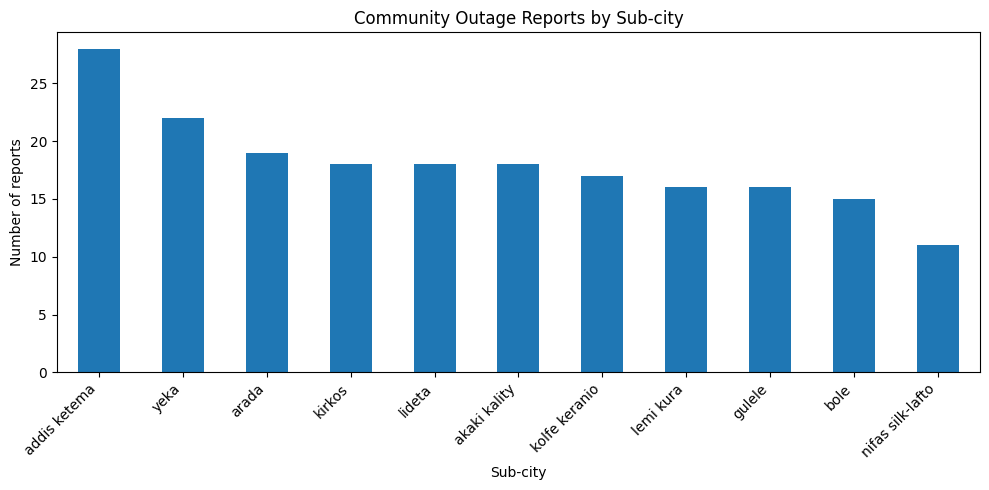

Most represented sub-city in the reports: addis ketema
This means most represented in the sample, not necessarily officially worst reliability.


In [6]:
if df.empty:
    raise ValueError("No cleaned reports available for analysis.")

# Plot 1: report count by sub-city
report_counts = df["sub_city"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
report_counts.plot(kind="bar")
plt.title("Community Outage Reports by Sub-city")
plt.xlabel("Sub-city")
plt.ylabel("Number of reports")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Most represented sub-city in the reports:", report_counts.index[0])
print("This means most represented in the sample, not necessarily officially worst reliability.")

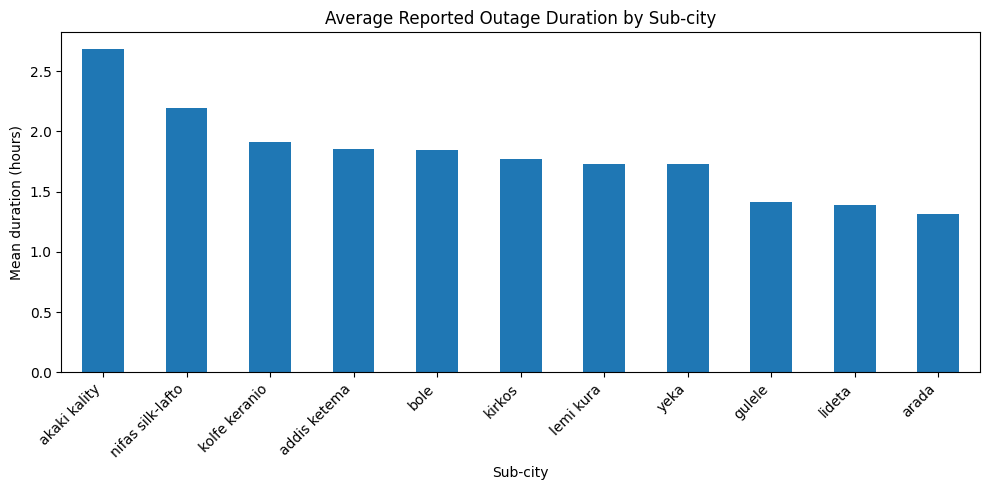

,mean_duration_hours
sub_city,
akaki kality,2.69
nifas silk-lafto,2.20
kolfe keranio,1.91
addis ketema,1.85
bole,1.85
kirkos,1.77
lemi kura,1.73
yeka,1.73
gulele,1.42


In [7]:
# Plot 2: average duration by sub-city
duration_by_subcity = df.groupby("sub_city")["duration_hours"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
duration_by_subcity.plot(kind="bar")
plt.title("Average Reported Outage Duration by Sub-city")
plt.xlabel("Sub-city")
plt.ylabel("Mean duration (hours)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(duration_by_subcity.to_frame("mean_duration_hours").round(2))

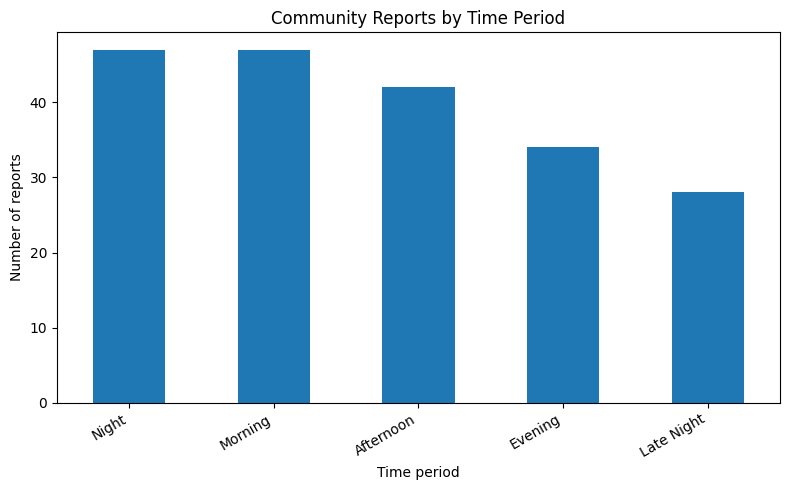

,report_count
time_period,
Night,47
Morning,47
Afternoon,42
Evening,34
Late Night,28


In [8]:
# Plot 3: reports by time period
period_order = ["Night", "Morning", "Afternoon", "Evening", "Late Night"]
time_counts = df["time_period"].value_counts().reindex(period_order).fillna(0)

plt.figure(figsize=(8, 5))
time_counts.plot(kind="bar")
plt.title("Community Reports by Time Period")
plt.xlabel("Time period")
plt.ylabel("Number of reports")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(time_counts.to_frame("report_count"))

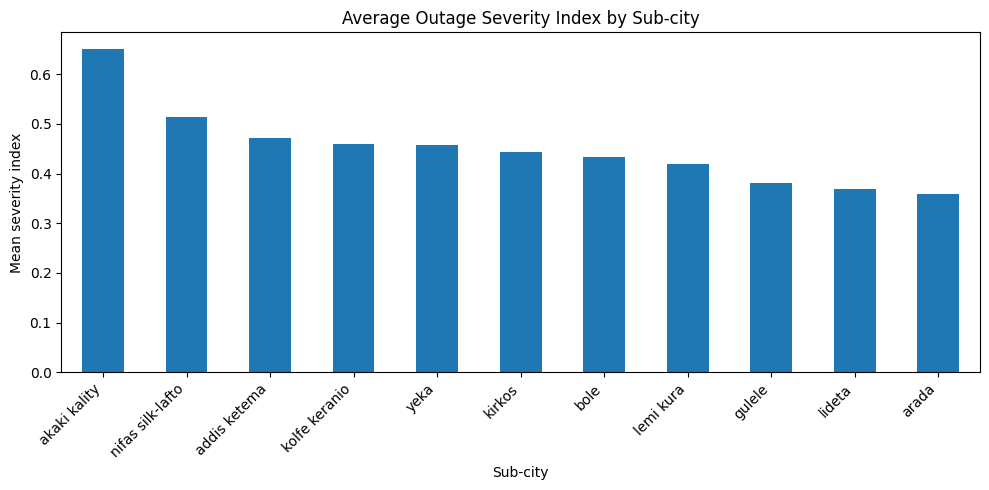

,mean_severity_index
sub_city,
akaki kality,0.652
nifas silk-lafto,0.515
addis ketema,0.472
kolfe keranio,0.459
yeka,0.458
kirkos,0.444
bole,0.433
lemi kura,0.420
gulele,0.381


In [9]:
# Plot 4: average severity index by sub-city
severity_by_subcity = df.groupby("sub_city")["severity_index"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
severity_by_subcity.plot(kind="bar")
plt.title("Average Outage Severity Index by Sub-city")
plt.xlabel("Sub-city")
plt.ylabel("Mean severity index")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(severity_by_subcity.to_frame("mean_severity_index").round(3))

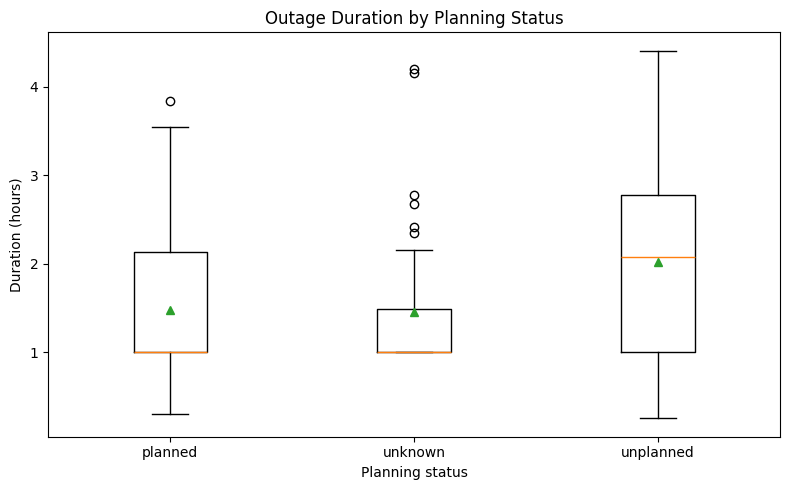

,count,mean,std,min,25%,50%,75%,max
planned_notice,,,,,,,,
planned,46.0,1.47,0.86,0.30,1.0,1.00,2.13,3.84
unknown,34.0,1.46,0.88,1.00,1.0,1.00,1.48,4.20
unplanned,118.0,2.01,1.05,0.25,1.0,2.08,2.78,4.41


In [10]:
# Plot 5: duration by planned/unplanned status
groups = [group["duration_hours"].values for _, group in df.groupby("planned_notice") if len(group) > 0]
labels = [name for name, group in df.groupby("planned_notice") if len(group) > 0]

plt.figure(figsize=(8, 5))
plt.boxplot(groups, labels=labels, showmeans=True)
plt.title("Outage Duration by Planning Status")
plt.xlabel("Planning status")
plt.ylabel("Duration (hours)")
plt.tight_layout()
plt.show()

display(df.groupby("planned_notice")["duration_hours"].describe().round(2))

### What the exploratory analysis shows

The plots above summarize the collected community reports. The first plot shows where reports came from. The duration and severity plots are more useful for understanding burden because longer and more disruptive outages matter more to daily life. The time-period plot connects the analysis to how people experience outages: interruptions during study, work, or business hours may create greater disruption than the same duration at a low-activity time.

These findings are early signals from a community sample. They are not official electricity reliability measurements.

## 7. Kujenga method 1: hypothesis testing

The Kujenga runners lesson uses a t-test to compare two groups. Here, I use the same statistical idea for a local electricity question:

**Question:** Are reported outages during rainy/stormy conditions longer than reported outages during non-rainy conditions?

\[
H_0: \mu_{\text{rainy}} = \mu_{\text{non-rainy}}
\]

\[
H_1: \mu_{\text{rainy}} > \mu_{\text{non-rainy}}
\]

I use Welch's two-sample t-test because the two groups may have different variances.

\[
t =
\frac{\bar{x}_1 - \bar{x}_2}
{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}
\]

In [11]:
rainy = df[df["is_rainy"] == 1]["duration_hours"].dropna()
non_rainy = df[df["is_rainy"] == 0]["duration_hours"].dropna()

print("Rainy/stormy reports:", len(rainy))
print("Non-rainy reports:", len(non_rainy))

if len(rainy) >= 2 and len(non_rainy) >= 2:
    t_stat, p_value = ttest_ind(rainy, non_rainy, alternative="greater", equal_var=False)
    print("Mean duration, rainy/stormy:", round(rainy.mean(), 3))
    print("Mean duration, non-rainy:", round(non_rainy.mean(), 3))
    print("t-statistic:", round(float(t_stat), 4))
    print("p-value:", round(float(p_value), 6))

    alpha = 0.05
    if p_value < alpha:
        print("Decision: Reject H0 at alpha=0.05.")
        print("Interpretation: In this sample, rainy/stormy reports have significantly longer duration.")
    else:
        print("Decision: Fail to reject H0 at alpha=0.05.")
        print("Interpretation: This sample does not provide enough evidence that rainy/stormy reports are longer.")
else:
    print("Not enough observations in one or both groups for a reliable t-test.")

Rainy/stormy reports: 52
Non-rainy reports: 146
Mean duration, rainy/stormy: 2.498
Mean duration, non-rainy: 1.541
t-statistic: 6.9324
p-value: 0.0
Decision: Reject H0 at alpha=0.05.
Interpretation: In this sample, rainy/stormy reports have significantly longer duration.


## 8. Kujenga method 2: regression

Regression is useful when we want to explain or predict a numerical outcome. Here, the outcome is outage duration in hours.

\[
\text{duration\_hours} =
\beta_0 +
\beta_1(\text{hour}) +
\beta_2(\text{is\_rainy}) +
\beta_3(\text{is\_planned}) +
\beta_4(\text{is\_weekend}) +
\beta_5(\text{sub\_city}) +
\epsilon
\]

The regression model estimates associations, not guaranteed causal effects. For example, if rainy weather is associated with longer duration, that does not prove rain caused the outage. It means the reports in this sample show that relationship.

The regression model minimizes the sum of squared errors:

\[
SSE = \sum_i (y_i - \hat{y}_i)^2
\]

In [12]:
reg_df = df.dropna(subset=["duration_hours", "hour", "sub_city", "is_rainy", "is_planned", "is_weekend"]).copy()

print("Rows available for regression:", len(reg_df))

if len(reg_df) >= 8 and reg_df["duration_hours"].nunique() > 1:
    # Use sub-city fixed effects only when there are enough rows.
    n_subcities = reg_df["sub_city"].nunique()
    if len(reg_df) >= n_subcities + 8:
        formula = "duration_hours ~ hour + is_weekend + is_rainy + is_planned + C(sub_city)"
    else:
        formula = "duration_hours ~ hour + is_weekend + is_rainy + is_planned"

    ols_model = smf.ols(formula, data=reg_df).fit()
    print("Regression formula:", formula)
    print(ols_model.summary())

    coef_table = ols_model.params.to_frame("coefficient")
    coef_table["p_value"] = ols_model.pvalues
    display(coef_table.round(4))
else:
    print("Not enough valid rows or variation to fit a meaningful regression model.")

Rows available for regression: 198
Regression formula: duration_hours ~ hour + is_weekend + is_rainy + is_planned + C(sub_city)
                            OLS Regression Results                            
Dep. Variable:         duration_hours   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     7.158
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.00e-11
Time:                        15:00:08   Log-Likelihood:                -239.41
No. Observations:                 198   AIC:                             508.8
Df Residuals:                     183   BIC:                             558.1
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [

,coefficient,p_value
Intercept,1.5847,0.0000
C(sub_city)[T.akaki kality],0.8944,0.0007
C(sub_city)[T.arada],-0.4529,0.0770
C(sub_city)[T.bole],-0.0302,0.9118
C(sub_city)[T.gulele],-0.4025,0.1323
C(sub_city)[T.kirkos],-0.0349,0.8916
C(sub_city)[T.kolfe keranio],0.0445,0.8668
C(sub_city)[T.lemi kura],-0.1864,0.4834
C(sub_city)[T.lideta],-0.5011,0.0511
C(sub_city)[T.nifas silk-lafto],0.5350,0.0817


## 9. Machine learning prototype: high-risk outage classification

The organizers asked us to avoid synthetic datasets if possible, so this model uses the collected community reports only. Because the dataset is still small, I treat the machine-learning results as a **proof-of-concept**, not as operational forecasting accuracy.

Target:

\[
y =
\begin{cases}
1, & \text{high-risk outage report}\\
0, & \text{lower-risk outage report}
\end{cases}
\]

For logistic regression, the model estimates:

\[
P(y=1|x) = \sigma(w^T x + b)
\]

where:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

and \(x\) is a feature vector containing time, weather, planning status, location, source type, and confidence score.

For classification, a common loss function is binary cross-entropy:

\[
L = -\frac{1}{N}\sum_i \left[y_i \log(p_i) + (1-y_i)\log(1-p_i)\right]
\]

I compare the machine-learning models to a dummy baseline. This is important because a model should beat a simple rule before we trust it.

In [13]:
features = [
    "hour", "is_weekend", "is_rainy", "is_planned",
    "sub_city", "time_period", "source_type", "confidence_score"
]
target = "high_risk_outage"

# Keep only available features.
features = [col for col in features if col in df.columns]

model_df = df[features + [target]].copy()
model_df = model_df.dropna(subset=[target])
model_df[target] = model_df[target].astype(int)

# For categorical features, convert pandas category type to string to avoid downstream issues.
for col in model_df.select_dtypes(include=["category"]).columns:
    model_df[col] = model_df[col].astype(str)

X = model_df[features]
y = model_df[target]

print("Rows available for ML:", len(model_df))
print("Target distribution:")
display(y.value_counts().to_frame("count"))

numeric_features = [col for col in ["hour", "is_weekend", "is_rainy", "is_planned", "confidence_score"] if col in features]
categorical_features = [col for col in features if col not in numeric_features]

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), categorical_features)
    ],
    remainder="drop"
)

models = {
    "dummy_baseline": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

min_class_count = int(y.value_counts().min()) if y.nunique() == 2 else 0

if y.nunique() < 2:
    print("The target has only one class, so classification cannot be evaluated yet.")
elif len(model_df) < 10 or min_class_count < 2:
    print("The dataset is too small for reliable cross-validation.")
    print("This section defines the model pipeline, but more reports are needed for evaluation.")
else:
    n_splits = min(5, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    scoring = {
        "accuracy": "accuracy",
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": make_scorer(recall_score, zero_division=0),
        "f1": make_scorer(f1_score, zero_division=0),
        "roc_auc": "roc_auc"
    }

    results = []
    fitted_pipelines = {}

    for name, clf in models.items():
        pipe = Pipeline([("preprocess", preprocess), ("model", clf)])
        cv_scores = cross_validate(
            pipe, X, y, cv=cv, scoring=scoring,
            return_train_score=False, error_score=np.nan
        )
        row = {"model": name, "cv_folds": n_splits}
        for metric in scoring:
            values = cv_scores[f"test_{metric}"]
            row[f"{metric}_mean"] = np.nanmean(values)
            row[f"{metric}_std"] = np.nanstd(values)
        results.append(row)

        pipe.fit(X, y)
        fitted_pipelines[name] = pipe

    results_df = pd.DataFrame(results).sort_values("f1_mean", ascending=False)
    display(results_df.round(3))

    best_model_name = results_df.iloc[0]["model"]
    best_pipe = fitted_pipelines[best_model_name]

    print("Best model by cross-validated F1:", best_model_name)

    # Cross-validated confusion matrix for the best model.
    y_pred_cv = cross_val_predict(best_pipe, X, y, cv=cv)
    cm = confusion_matrix(y, y_pred_cv, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["actual_0", "actual_1"], columns=["pred_0", "pred_1"])
    print("Cross-validated confusion matrix:")
    display(cm_df)

Rows available for ML: 198
Target distribution:


,count
high_risk_outage,
0,112
1,86


,model,cv_folds,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,random_forest,5,0.773,0.024,0.766,0.073,0.710,0.103,0.728,0.036,0.863,0.049
1,logistic_regression,5,0.768,0.034,0.813,0.012,0.604,0.103,0.688,0.067,0.819,0.032
0,dummy_baseline,5,0.566,0.009,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000


Best model by cross-validated F1: random_forest


Cross-validated confusion matrix:


,pred_0,pred_1
actual_0,92,20
actual_1,25,61


,feature,importance_mean,importance_std
7,confidence_score,0.2245,0.0340
4,sub_city,0.1667,0.0193
2,is_rainy,0.1168,0.0236
5,time_period,0.0634,0.0144
3,is_planned,0.0589,0.0126
0,hour,0.0346,0.0124
1,is_weekend,0.0214,0.0092
6,source_type,0.0000,0.0000


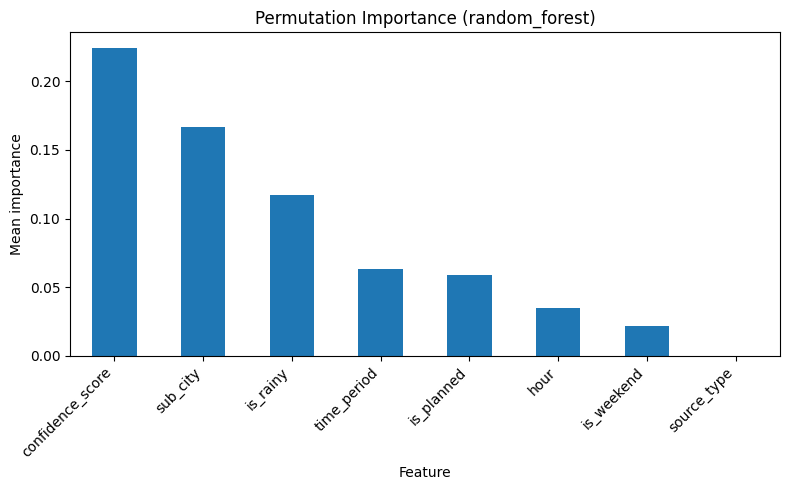

In [14]:
# Optional feature importance for the best non-dummy model if evaluation was possible.
if "fitted_pipelines" in globals() and y.nunique() == 2 and len(model_df) >= 10 and min_class_count >= 2:
    preferred_model_name = "random_forest" if "random_forest" in fitted_pipelines else best_model_name
    importance_pipe = fitted_pipelines[preferred_model_name]

    try:
        perm = permutation_importance(
            importance_pipe, X, y,
            scoring=make_scorer(f1_score, zero_division=0),
            n_repeats=20,
            random_state=RANDOM_STATE
        )
        importance_df = pd.DataFrame({
            "feature": X.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std
        }).sort_values("importance_mean", ascending=False)

        display(importance_df.round(4))

        plt.figure(figsize=(8, 5))
        importance_df.set_index("feature")["importance_mean"].plot(kind="bar")
        plt.title(f"Permutation Importance ({preferred_model_name})")
        plt.xlabel("Feature")
        plt.ylabel("Mean importance")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print("Feature importance could not be computed:", exc)
else:
    print("Feature importance skipped because the dataset is still too small or has only one target class.")

## 10. Model card and responsible AI

| Item | Description |
|---|---|
| Project name | GridSense |
| Model purpose | Explore outage severity/risk patterns from anonymous community reports |
| Intended use | Student research, awareness, and planning prototype |
| Not intended for | Official outage alerts, emergency decisions, or replacing electricity utility communication |
| Main data | Anonymous community outage reports |
| Privacy protection | No names, phone numbers, exact addresses, emails, or personal IDs |
| Main limitation | Community sample may be non-random and uneven across Addis Ababa |
| Main risk | A model trained on small or biased data may sound more certain than it really is |
| Responsible interpretation | Treat results as early signals, not official reliability measurements |
| Next improvement | Collect more reports, add official interruption notices, connect real weather data, and validate predictions over time |

## 11. Automatic finding summary

This cell prints a short evidence-based summary from the cleaned dataset. I use it to make sure the conclusion is grounded in the actual data, not just a general claim.

In [15]:
print("Cleaned community reports:", len(df))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

if len(df) > 0:
    top_report_area = df["sub_city"].value_counts().idxmax()
    top_duration_area = df.groupby("sub_city")["duration_hours"].mean().idxmax()
    top_severity_area = df.groupby("sub_city")["severity_index"].mean().idxmax()
    most_common_period = df["time_period"].value_counts().idxmax()

    print("Most represented sub-city in reports:", top_report_area)
    print("Highest average duration sub-city:", top_duration_area)
    print("Highest average severity-index sub-city:", top_severity_area)
    print("Most common time period in reports:", most_common_period)
    print("Average reported duration:", round(df["duration_hours"].mean(), 2), "hours")
    print("Average severity index:", round(df["severity_index"].mean(), 3))

Cleaned community reports: 198
Date range: 2026-04-12 to 2026-04-29
Most represented sub-city in reports: addis ketema
Highest average duration sub-city: akaki kality
Highest average severity-index sub-city: akaki kality
Most common time period in reports: Night
Average reported duration: 1.79 hours
Average severity index: 0.451


## 12. Limitations

This project is intentionally honest about what the data can and cannot support.

1. **The dataset is community-reported.** It may not represent all Addis Ababa residents equally.
2. **Report counts are not official outage frequencies.** An area with more reports may simply have more respondents.
3. **The sample size may still be small.** Machine-learning results should be treated as proof-of-concept unless the dataset becomes much larger.
4. **Weather labels may be approximate.** If respondents reported weather manually, there can be uncertainty.
5. **This is not an official forecasting system.** It is a local data science project showing how outage reports can be structured and analyzed responsibly.

These limitations do not make the project weak. They make the interpretation responsible.

## 13. Future work: from project to useful system

The next version of GridSense could become much more powerful by adding:

1. More anonymous reports from more sub-cities and sefers.
2. Official interruption notices where available.
3. Real hourly weather data from a weather API.
4. A Streamlit reporting form that stores only non-personal data.
5. A dashboard showing trends, severity, and model uncertainty.
6. A calibrated model that is evaluated over time, not just on one small dataset.

A useful future system should not say “an outage will definitely happen.” It should say something more responsible, such as:

> Based on current evidence and past reports, this location/time has higher reported outage risk than usual.

## 14. Conclusion

This project investigated electricity outage patterns in Addis Ababa using anonymous community reports. I chose this topic because it is a local problem that affects studying, internet access, households, and small businesses. Instead of using a synthetic dataset as the main evidence, I collected and analyzed real community-reported data while avoiding personal information.

The notebook followed a complete Kujenga-style workflow:

1. Start with a local real-world problem.
2. Collect and describe data.
3. Clean and protect the data.
4. Engineer useful features.
5. Visualize patterns by time, location, duration, and severity.
6. Use hypothesis testing to compare rainy/stormy and non-rainy reports.
7. Use regression to explain outage duration.
8. Build a cautious machine-learning prototype for high-risk outage classification.
9. Explain limitations and responsible use.

The main lesson is that even a small anonymous dataset can begin to reveal useful local patterns, but it should not be overclaimed. With more reports, official notices, and real weather integration, GridSense could grow into a practical outage-awareness and planning tool for Addis Ababa.

## 15. Submission checklist

Before submitting:

- [ ] The notebook filename is `lisanegebriel_ethiopia_final_project.ipynb`.
- [ ] The GitHub repository contains this notebook.
- [ ] The GitHub repository contains the dataset CSV used by the notebook.
- [ ] The dataset does not contain personal information.
- [ ] The notebook runs from top to bottom without errors.
- [ ] The notebook shows visualizations and a final conclusion.
- [ ] The README explains the project and how to run it.